In [1]:
import numpy as np
import pandas as pd #สำหรับแดสงข้อมูลตาราง
import seaborn as sns
import matplotlib.pyplot as plt # สำหรับทำกราฟ
import plotly.express as px
import plotly.graph_objects as go


In [2]:
# import mediapipe as mp
# สำหรับรวมข้อมูล
import os
import json
import cv2 # นอกจากจะใช้เปิดกล้องแล้ว ยังใช้รมค่าสีมาเป็นรุปได้ด้วย
import glob
import xml.etree.ElementTree as ET


# Data cleaning

- **เช็คข้อมูลเบื้องต้น**

In [3]:
import kagglehub

base_path = kagglehub.dataset_download("kapitanov/hagrid")

print("path to data set files:", base_path)
print("list name folder:", os.listdir(base_path))

print("---------------------------")
target_folder = os.path.join(base_path, "ann_train_val")
print("path to data set files:", target_folder)
print(os.listdir(target_folder))

print("---------------------------")
target_files = os.path.join(base_path, "ann_train_val", "like.json")
print("path to data set files:", target_files)
# print(os.listdir(target_files))

print("---------------------------")
test_flies = os.path.join(base_path, "ann_test")
print("path to data set files:", test_flies)
print(os.listdir(test_flies))


100%|██████████| 338M/338M [00:02<00:00, 128MB/s]

Extracting files...


path to data set files: /root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3
list name folder: ['ann_test', 'ann_train_val', 'ann_subsample']
---------------------------
path to data set files: /root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3/ann_train_val
['stop.json', 'two_up_inverted.json', 'rock.json', 'peace.json', 'like.json', 'one.json', 'dislike.json', 'peace_inverted.json', 'fist.json', 'two_up.json', 'four.json', 'palm.json', 'ok.json', 'call.json', 'three2.json', 'stop_inverted.json', 'three.json', 'mute.json']
---------------------------
path to data set files: /root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3/ann_train_val/like.json
---------------------------
path to data set files: /root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3/ann_test
['stop.json', 'two_up_inverted.json', 'rock.json', 'peace.json', 'like.json', 'one.json', 'dislike.json', 'peace_inverted.json', 'fist.json', 'two_up.json', 'four.json', 'palm.json', 'ok.json', 'ca

In [4]:
# base_path = "/kaggle/input/hagrid"
base_path = "/root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3"
json_file_path = os.path.join(base_path, "ann_train_val", "like.json")

df_test = pd.json_normalize(pd.read_json(json_file_path, orient='index').to_dict(orient='records'))

# 3. สั่งแสดงผลตาราง 5 แถวแรกขึ้นมาดูเช็กสุขภาพข้อมูล
df_test.head()



,bboxes,labels,landmarks,leading_conf,leading_hand,user_id
0,"[[0.31371071, 0.40165019999999996, 0.14489726,...",[like],"[[[0.311729990870386, 0.514619094561327], [0.3...",1.0,right,76b71b86e95ecc1437aa2f3c11ef33caf49b00e27672fb...
1,"[[0.34835416, 0.86326408, 0.25937015, 0.129737...","[no_gesture, like]","[[[0.35544432328385, 0.9178467912811511], [0.3...",1.0,left,470ddc36334dff75157345b42b964b1c2132c2acc3b886...
2,"[[0.36631962, 0.39287258, 0.11244454, 0.112485...","[like, no_gesture]","[[[0.369505101970231, 0.477687113953965], [0.3...",1.0,right,927a54654801ddd904e55b8ad778c3550b4aac2f380090...
3,"[[0.5243052, 0.41280832, 0.07708628000000001, ...",[like],"[[[0.59565514783339, 0.5572043414973951], [0.5...",1.0,left,6bd44d7ed4e1e0eabbe2e950dde3e7b08deecfebbabd67...
4,"[[0.45937984, 0.34604341, 0.03552589, 0.032280...",[like],"[[[0.464072040957047, 0.368714317513721], [0.4...",1.0,right,5de423c55f56eaea795eeee9665d949328d901f3c968ea...


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27721 entries, 0 to 27720
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bboxes        27721 non-null  object 
 1   labels        27721 non-null  object 
 2   landmarks     27721 non-null  object 
 3   leading_conf  27721 non-null  float64
 4   leading_hand  27721 non-null  object 
 5   user_id       27721 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.3+ MB


In [6]:
# df.duplicated().sum()
df_test.duplicated(subset=['leading_hand']).sum()

np.int64(27719)

In [7]:
# df[df.duplicated()]
df_test[df_test.duplicated(subset=['user_id'], keep=False)]

,bboxes,labels,landmarks,leading_conf,leading_hand,user_id
0,"[[0.31371071, 0.40165019999999996, 0.14489726,...",[like],"[[[0.311729990870386, 0.514619094561327], [0.3...",1.0,right,76b71b86e95ecc1437aa2f3c11ef33caf49b00e27672fb...
1,"[[0.34835416, 0.86326408, 0.25937015, 0.129737...","[no_gesture, like]","[[[0.35544432328385, 0.9178467912811511], [0.3...",1.0,left,470ddc36334dff75157345b42b964b1c2132c2acc3b886...
2,"[[0.36631962, 0.39287258, 0.11244454, 0.112485...","[like, no_gesture]","[[[0.369505101970231, 0.477687113953965], [0.3...",1.0,right,927a54654801ddd904e55b8ad778c3550b4aac2f380090...
3,"[[0.5243052, 0.41280832, 0.07708628000000001, ...",[like],"[[[0.59565514783339, 0.5572043414973951], [0.5...",1.0,left,6bd44d7ed4e1e0eabbe2e950dde3e7b08deecfebbabd67...
4,"[[0.45937984, 0.34604341, 0.03552589, 0.032280...",[like],"[[[0.464072040957047, 0.368714317513721], [0.4...",1.0,right,5de423c55f56eaea795eeee9665d949328d901f3c968ea...
...,...,...,...,...,...,...
27716,"[[0.44399575, 0.43545489, 0.06375945, 0.168955...",[like],"[[[0.44756061406262904, 0.5489020885034], [0.4...",1.0,right,b26848c7747898f59dc5c8bb4db02d7e7c74bd30f58efb...
27717,"[[0.18235536, 0.56124977, 0.22736709, 0.213050...",[like],"[[[0.40364455247277503, 0.7338187390020701], [...",1.0,left,604ee0fe2ba400d77a6bd7eade2da2f21d173085fb7a13...
27718,"[[0.37857905000000003, 0.44062, 0.19728857, 0....",[like],"[[[0.388457252168524, 0.5815576244322801], [0....",1.0,right,56ae1f0c89982eecdc35202a758c1fbc1196a1e399cdec...
27719,"[[0.38097883, 0.58226702, 0.10323605, 0.076319...",[like],"[[[0.380561764080998, 0.6389204468805101], [0....",1.0,right,c9987c68f2d17f2e5cffe60c998f20e5c7640e0863bfb6...


In [8]:
df_test.isna().sum()

,0
bboxes,0
labels,0
landmarks,0
leading_conf,0
leading_hand,0
user_id,0


In [9]:
df_test.describe()

,leading_conf
count,27721.000000
mean,0.989186
std,0.045667
min,0.600000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [10]:
# print(df_test['bboxes'].value_counts())
print(df_test['labels'].value_counts())
print("--------------------------------")
# print(df_test['landmarks'].value_counts())
print(df_test['leading_conf'].value_counts())
print("--------------------------------")
print(df_test['leading_hand'].value_counts())

labels
[like]                20484
[like, no_gesture]     4023
[no_gesture, like]     3214
Name: count, dtype: int64
--------------------------------
leading_conf
1.000000    26143
0.800000     1305
0.900000      124
0.916667       93
0.600000       41
0.909091        8
0.833333        4
0.750000        1
0.700000        1
0.727273        1
Name: count, dtype: int64
--------------------------------
leading_hand
right    15212
left     12509
Name: count, dtype: int64


- **เอาข้อมูลjsonมาของทุกท่ามารวมกัน และทำdata สำหรับเทรน**

In [11]:
# Base_Path = "/kaggle/input/hagrid/ann_train_val"
Base_Path = "/root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3/ann_train_val"
# Img_Path = "/kaggle/input/hagrid/train"
Img_Path = "/root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3/train"

all_data = []

json_files = glob.glob(os.path.join(Base_Path, "*.json"))

for json_file in json_files:
  # gesture_name = os.path.basename(json_file).replace('.json', '')
  with open(json_file, 'r') as f:
    annotations = json.load(f)
  for img_name, ann in annotations.items():
      all_data.append({
          # 'img_path': os.path.join(Img_Path, gesture_name, img_name + '.jpg'),
          'img_path': os.path.join(Img_Path , img_name + '.jpg'),
          'user_id': ann['user_id'],
          'bbox': ann['bboxes'][0] if ann['bboxes'] else None,
          # 'labels': gesture_name,
          'labels': ann['labels'],
          'landmarks': ann['landmarks'] if ann['landmarks'] else None,
          'leading_conf': ann['leading_conf'] if ann['leading_conf'] else None,
          'leading_hand': ann['leading_hand'] if ann['leading_hand'] else None

      })

print(f"รูปทั้งหมด: {len(all_data)}")

รูปทั้งหมด: 509323


In [12]:
# ตัวอย่าง df = pd.read_csv("/kaggle/input/bank-customer-churn-prediction/Churn_Modelling.csv")

#แปลง ไฟล์จาก json ให้เอามาเทรนได้
df = pd.DataFrame(all_data)

df.head()


,img_path,user_id,bbox,labels,landmarks,leading_conf,leading_hand
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,14aec16438481ebcd54da62b6e80d282032e69db6fccd8...,"[0.60298308, 0.27713193, 0.21705335, 0.24402637]",[stop],"[[[0.74884646679025, 0.5068855890588878], [0.6...",1.0,left
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,c27c15e69fb642a820e468feb5a606b02674a00f5acc48...,"[0.19313192, 0.35934433, 0.13566566, 0.18734354]",[stop],"[[[0.2407914691190961, 0.5338434047510898], [0...",1.0,right
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,86d1f4ec4b67e6e9ee603333f55d941c1bc7075c130d27...,"[0.43238101, 0.23930129, 0.04156717, 0.1309078]","[stop, no_gesture]","[[[0.4504239226445521, 0.3490439985550189], [0...",1.0,right
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,ff8f6172d1015830a31aba0ae5de2405bb14f2c67cae01...,"[0.51976587, 0.37458101, 0.05858516, 0.06814756]","[stop, no_gesture]","[[[0.5430011702309137, 0.4355095829194132], [0...",1.0,right
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,158a07f464cb46cde8cbd5c1f835a96b970364bc422e6a...,"[0.2368232, 0.26388516, 0.11742428, 0.23581455]",[stop],"[[[0.2702468461835846, 0.46940978138165035], [...",1.0,right


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509323 entries, 0 to 509322
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   img_path      509323 non-null  object 
 1   user_id       509323 non-null  object 
 2   bbox          509323 non-null  object 
 3   labels        509323 non-null  object 
 4   landmarks     509323 non-null  object 
 5   leading_conf  509323 non-null  float64
 6   leading_hand  509323 non-null  object 
dtypes: float64(1), object(6)
memory usage: 27.2+ MB


In [14]:
df.duplicated(subset=['leading_hand']).sum()

np.int64(509321)

In [15]:
df[df.duplicated(subset=['user_id'], keep=False)]

,img_path,user_id,bbox,labels,landmarks,leading_conf,leading_hand
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,14aec16438481ebcd54da62b6e80d282032e69db6fccd8...,"[0.60298308, 0.27713193, 0.21705335, 0.24402637]",[stop],"[[[0.74884646679025, 0.5068855890588878], [0.6...",1.0,left
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,c27c15e69fb642a820e468feb5a606b02674a00f5acc48...,"[0.19313192, 0.35934433, 0.13566566, 0.18734354]",[stop],"[[[0.2407914691190961, 0.5338434047510898], [0...",1.0,right
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,86d1f4ec4b67e6e9ee603333f55d941c1bc7075c130d27...,"[0.43238101, 0.23930129, 0.04156717, 0.1309078]","[stop, no_gesture]","[[[0.4504239226445521, 0.3490439985550189], [0...",1.0,right
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,ff8f6172d1015830a31aba0ae5de2405bb14f2c67cae01...,"[0.51976587, 0.37458101, 0.05858516, 0.06814756]","[stop, no_gesture]","[[[0.5430011702309137, 0.4355095829194132], [0...",1.0,right
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,158a07f464cb46cde8cbd5c1f835a96b970364bc422e6a...,"[0.2368232, 0.26388516, 0.11742428, 0.23581455]",[stop],"[[[0.2702468461835846, 0.46940978138165035], [...",1.0,right
...,...,...,...,...,...,...,...
509318,/root/.cache/kagglehub/datasets/kapitanov/hagr...,33f24b9705142908f1dad6d190bcd08dbf809b3ebdcaaf...,"[0.42219537, 0.33078677, 0.10278819, 0.12971357]",[mute],"[[[0.4384888085587919, 0.44665257896232796], [...",1.0,right
509319,/root/.cache/kagglehub/datasets/kapitanov/hagr...,0d6da2c87ef8eabeda2dcfee2dc5b5035e878137a91b14...,"[0.41804541, 0.49816814, 0.10928455, 0.1417775]",[mute],"[[[0.5007987596472572, 0.6288031341642086], [0...",1.0,left
509320,/root/.cache/kagglehub/datasets/kapitanov/hagr...,53077b819f7acc32945df2f854d8280e43f93930b4cd59...,"[0.40165368, 0.25615628, 0.30457509, 0.3069493]",[mute],"[[[0.45797755374205434, 0.533840795954256], [0...",1.0,right
509321,/root/.cache/kagglehub/datasets/kapitanov/hagr...,bf8d4f1f606fb5401f0a913a28586c277606eb0f7d8a62...,"[0.43349375, 0.52375, 0.14897375, 0.4735075]",[mute],"[[[0.5345443540424876, 1.0071077951678635], [0...",0.8,left


In [16]:
df.isna().sum()

,0
img_path,0
user_id,0
bbox,0
labels,0
landmarks,0
leading_conf,0
leading_hand,0


In [17]:
df.describe()

,leading_conf
count,509323.000000
mean,0.990970
std,0.043044
min,0.600000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [18]:
# df[df.duplicated()]
# df.duplicated().sum()

In [19]:
# print(df_test['bboxes'].value_counts())
print(df['labels'].value_counts())
print("--------------------------------")
# print(df_test['landmarks'].value_counts())
print(df['leading_conf'].value_counts())
print("--------------------------------")
print(df['leading_hand'].value_counts())

labels
[two_up]                                     23730
[mute]                                       23344
[stop_inverted]                              22735
[call]                                       22590
[three2]                                     22562
[two_up_inverted]                            22319
[peace_inverted]                             22318
[peace]                                      22118
[four]                                       22032
[fist]                                       22008
[palm]                                       21982
[stop]                                       21851
[dislike]                                    21590
[ok]                                         21469
[three]                                      21263
[rock]                                       21119
[one]                                        21071
[like]                                       20484
[one, no_gesture]                             4140
[like, no_gesture]      

- เปลี่ยนข้อมุลlabels และช้อมูลที่เป็นข้อความให้เป็นตัวเลขเพื่อใช้ในการเทรน

In [20]:
df

,img_path,user_id,bbox,labels,landmarks,leading_conf,leading_hand
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,14aec16438481ebcd54da62b6e80d282032e69db6fccd8...,"[0.60298308, 0.27713193, 0.21705335, 0.24402637]",[stop],"[[[0.74884646679025, 0.5068855890588878], [0.6...",1.0,left
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,c27c15e69fb642a820e468feb5a606b02674a00f5acc48...,"[0.19313192, 0.35934433, 0.13566566, 0.18734354]",[stop],"[[[0.2407914691190961, 0.5338434047510898], [0...",1.0,right
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,86d1f4ec4b67e6e9ee603333f55d941c1bc7075c130d27...,"[0.43238101, 0.23930129, 0.04156717, 0.1309078]","[stop, no_gesture]","[[[0.4504239226445521, 0.3490439985550189], [0...",1.0,right
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,ff8f6172d1015830a31aba0ae5de2405bb14f2c67cae01...,"[0.51976587, 0.37458101, 0.05858516, 0.06814756]","[stop, no_gesture]","[[[0.5430011702309137, 0.4355095829194132], [0...",1.0,right
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,158a07f464cb46cde8cbd5c1f835a96b970364bc422e6a...,"[0.2368232, 0.26388516, 0.11742428, 0.23581455]",[stop],"[[[0.2702468461835846, 0.46940978138165035], [...",1.0,right
...,...,...,...,...,...,...,...
509318,/root/.cache/kagglehub/datasets/kapitanov/hagr...,33f24b9705142908f1dad6d190bcd08dbf809b3ebdcaaf...,"[0.42219537, 0.33078677, 0.10278819, 0.12971357]",[mute],"[[[0.4384888085587919, 0.44665257896232796], [...",1.0,right
509319,/root/.cache/kagglehub/datasets/kapitanov/hagr...,0d6da2c87ef8eabeda2dcfee2dc5b5035e878137a91b14...,"[0.41804541, 0.49816814, 0.10928455, 0.1417775]",[mute],"[[[0.5007987596472572, 0.6288031341642086], [0...",1.0,left
509320,/root/.cache/kagglehub/datasets/kapitanov/hagr...,53077b819f7acc32945df2f854d8280e43f93930b4cd59...,"[0.40165368, 0.25615628, 0.30457509, 0.3069493]",[mute],"[[[0.45797755374205434, 0.533840795954256], [0...",1.0,right
509321,/root/.cache/kagglehub/datasets/kapitanov/hagr...,bf8d4f1f606fb5401f0a913a28586c277606eb0f7d8a62...,"[0.43349375, 0.52375, 0.14897375, 0.4735075]",[mute],"[[[0.5345443540424876, 1.0071077951678635], [0...",0.8,left


In [21]:
df.columns.tolist()

['img_path',
 'user_id',
 'bbox',
 'labels',
 'landmarks',
 'leading_conf',
 'leading_hand']

In [22]:
df_before = df.copy()

In [23]:
# ตัดข้อมูล ที่ landmark มีข้อมูล2 มือ

# สร้าง mask เอาเฉพาะแถวที่มี 1 label
mask_train = df['labels'].apply(lambda x: len(x) == 1)
# mask_test  = df_exam['labels'].apply(lambda x: len(x) == 1)

df = df[mask_train].reset_index(drop=True)


In [24]:
df

,img_path,user_id,bbox,labels,landmarks,leading_conf,leading_hand
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,14aec16438481ebcd54da62b6e80d282032e69db6fccd8...,"[0.60298308, 0.27713193, 0.21705335, 0.24402637]",[stop],"[[[0.74884646679025, 0.5068855890588878], [0.6...",1.0,left
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,c27c15e69fb642a820e468feb5a606b02674a00f5acc48...,"[0.19313192, 0.35934433, 0.13566566, 0.18734354]",[stop],"[[[0.2407914691190961, 0.5338434047510898], [0...",1.0,right
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,158a07f464cb46cde8cbd5c1f835a96b970364bc422e6a...,"[0.2368232, 0.26388516, 0.11742428, 0.23581455]",[stop],"[[[0.2702468461835846, 0.46940978138165035], [...",1.0,right
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,5c939c9060786d3b52bacade031f73efb4ef57d7345003...,"[0.22837058, 0.48790017, 0.14907013, 0.14977066]",[stop],"[[[0.2754929542265349, 0.6307268622959118], [0...",1.0,right
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,f68fcf36aa57a3caf3eb5341b03ef9100515a65b3e4900...,"[0.60939167, 0.116825, 0.2000175, 0.39933278]",[stop],"[[[0.7428565518123607, 0.5079178810119629], [0...",1.0,left
...,...,...,...,...,...,...,...
396591,/root/.cache/kagglehub/datasets/kapitanov/hagr...,33f24b9705142908f1dad6d190bcd08dbf809b3ebdcaaf...,"[0.42219537, 0.33078677, 0.10278819, 0.12971357]",[mute],"[[[0.4384888085587919, 0.44665257896232796], [...",1.0,right
396592,/root/.cache/kagglehub/datasets/kapitanov/hagr...,0d6da2c87ef8eabeda2dcfee2dc5b5035e878137a91b14...,"[0.41804541, 0.49816814, 0.10928455, 0.1417775]",[mute],"[[[0.5007987596472572, 0.6288031341642086], [0...",1.0,left
396593,/root/.cache/kagglehub/datasets/kapitanov/hagr...,53077b819f7acc32945df2f854d8280e43f93930b4cd59...,"[0.40165368, 0.25615628, 0.30457509, 0.3069493]",[mute],"[[[0.45797755374205434, 0.533840795954256], [0...",1.0,right
396594,/root/.cache/kagglehub/datasets/kapitanov/hagr...,bf8d4f1f606fb5401f0a913a28586c277606eb0f7d8a62...,"[0.43349375, 0.52375, 0.14897375, 0.4735075]",[mute],"[[[0.5345443540424876, 1.0071077951678635], [0...",0.8,left


In [25]:
# แปลง ข้อมูลให้เป้น ตัวเลขต้องไม่มี list
bbox_df = pd.DataFrame(df['bbox'].tolist(),
                       columns=['bbox_x','bbox_y','bbox_w','bbox_h'],
                       index=df.index)

# แตก landmarks
landmarks_flat = df['landmarks'].apply(lambda x: np.array(x).flatten())
landmarks_df = pd.DataFrame(landmarks_flat.tolist(), index=df.index)
landmarks_df.columns = [f'lm_{i}' for i in range(landmarks_df.shape[1])]



In [26]:
# รวมกลับ
df = df.drop(columns=['bbox', 'landmarks'])
df = pd.concat([df, bbox_df, landmarks_df], axis=1)

# print(df.shape)
# print(df.dtypes)

In [27]:
df

,img_path,user_id,labels,leading_conf,leading_hand,bbox_x,bbox_y,bbox_w,bbox_h,lm_0,...,lm_32,lm_33,lm_34,lm_35,lm_36,lm_37,lm_38,lm_39,lm_40,lm_41
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,14aec16438481ebcd54da62b6e80d282032e69db6fccd8...,[stop],1.0,left,0.602983,0.277132,0.217053,0.244026,0.748846,...,0.726814,0.299502,0.777030,0.410223,0.772813,0.373181,0.766250,0.349655,0.758214,0.328843
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,c27c15e69fb642a820e468feb5a606b02674a00f5acc48...,[stop],1.0,right,0.193132,0.359344,0.135666,0.187344,0.240791,...,0.249028,0.382820,0.212635,0.462834,0.216432,0.436726,0.221086,0.420626,0.227980,0.405909
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,158a07f464cb46cde8cbd5c1f835a96b970364bc422e6a...,[stop],1.0,right,0.236823,0.263885,0.117424,0.235815,0.270247,...,0.301718,0.284260,0.260672,0.375566,0.267660,0.342575,0.273641,0.323235,0.279852,0.306531
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,5c939c9060786d3b52bacade031f73efb4ef57d7345003...,[stop],1.0,right,0.228371,0.487900,0.149070,0.149771,0.275493,...,0.293870,0.506286,0.255998,0.566511,0.259768,0.544606,0.264374,0.532564,0.270441,0.521814
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,f68fcf36aa57a3caf3eb5341b03ef9100515a65b3e4900...,[stop],1.0,left,0.609392,0.116825,0.200017,0.399333,0.742857,...,0.735877,0.158258,0.777613,0.347721,0.774857,0.284104,0.771644,0.244880,0.767785,0.209303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396591,/root/.cache/kagglehub/datasets/kapitanov/hagr...,33f24b9705142908f1dad6d190bcd08dbf809b3ebdcaaf...,[mute],1.0,right,0.422195,0.330787,0.102788,0.129714,0.438489,...,0.479489,0.423617,0.460506,0.405746,0.491388,0.424957,0.484961,0.435008,0.472204,0.433971
396592,/root/.cache/kagglehub/datasets/kapitanov/hagr...,0d6da2c87ef8eabeda2dcfee2dc5b5035e878137a91b14...,[mute],1.0,left,0.418045,0.498168,0.109285,0.141778,0.500799,...,0.456010,0.594137,0.486049,0.582142,0.448595,0.585265,0.447315,0.597304,0.456966,0.602316
396593,/root/.cache/kagglehub/datasets/kapitanov/hagr...,53077b819f7acc32945df2f854d8280e43f93930b4cd59...,[mute],1.0,right,0.401654,0.256156,0.304575,0.306949,0.457978,...,0.599462,0.463346,0.472038,0.440404,0.555480,0.429725,0.585034,0.452971,0.578374,0.470589
396594,/root/.cache/kagglehub/datasets/kapitanov/hagr...,bf8d4f1f606fb5401f0a913a28586c277606eb0f7d8a62...,[mute],0.8,left,0.433494,0.523750,0.148974,0.473508,0.534544,...,0.482555,0.901735,0.525747,0.853092,0.465277,0.871033,0.466157,0.915478,0.483665,0.934312


In [28]:
# df_dummies = pd.get_dummies(df[['leading_hand','Geography']], drop_first=False, dtype=int)
# df_dummies = pd.get_dummies(df[['leading_hand', 'labels']], drop_first=False, dtype=int)
df_dummies = pd.get_dummies(df[['leading_hand']], drop_first=False, dtype=int)

In [29]:
df_dummies

,leading_hand_left,leading_hand_right
0,1,0
1,0,1
2,0,1
3,0,1
4,1,0
...,...,...
396591,0,1
396592,1,0
396593,0,1
396594,1,0


In [30]:
# df = df.drop(columns=["Gender","Geography"])
# df = df.drop(columns=["leading_conf"])
df = df.drop(columns=["leading_hand", "img_path", "user_id" , "leading_conf"])

In [31]:
df = pd.concat([df, df_dummies], axis=1)

In [32]:
df

,labels,bbox_x,bbox_y,bbox_w,bbox_h,lm_0,lm_1,lm_2,lm_3,lm_4,...,lm_34,lm_35,lm_36,lm_37,lm_38,lm_39,lm_40,lm_41,leading_hand_left,leading_hand_right
0,[stop],0.602983,0.277132,0.217053,0.244026,0.748846,0.506886,0.690487,0.498133,0.646612,...,0.777030,0.410223,0.772813,0.373181,0.766250,0.349655,0.758214,0.328843,1,0
1,[stop],0.193132,0.359344,0.135666,0.187344,0.240791,0.533843,0.284629,0.517270,0.302835,...,0.212635,0.462834,0.216432,0.436726,0.221086,0.420626,0.227980,0.405909,0,1
2,[stop],0.236823,0.263885,0.117424,0.235815,0.270247,0.469410,0.299763,0.469127,0.322262,...,0.260672,0.375566,0.267660,0.342575,0.273641,0.323235,0.279852,0.306531,0,1
3,[stop],0.228371,0.487900,0.149070,0.149771,0.275493,0.630727,0.317255,0.620785,0.342533,...,0.255998,0.566511,0.259768,0.544606,0.264374,0.532564,0.270441,0.521814,0,1
4,[stop],0.609392,0.116825,0.200017,0.399333,0.742857,0.507918,0.683589,0.486247,0.639697,...,0.777613,0.347721,0.774857,0.284104,0.771644,0.244880,0.767785,0.209303,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396591,[mute],0.422195,0.330787,0.102788,0.129714,0.438489,0.446653,0.470890,0.443630,0.490260,...,0.460506,0.405746,0.491388,0.424957,0.484961,0.435008,0.472204,0.433971,0,1
396592,[mute],0.418045,0.498168,0.109285,0.141778,0.500799,0.628803,0.464326,0.618111,0.449632,...,0.486049,0.582142,0.448595,0.585265,0.447315,0.597304,0.456966,0.602316,1,0
396593,[mute],0.401654,0.256156,0.304575,0.306949,0.457978,0.533841,0.529363,0.515547,0.579041,...,0.472038,0.440404,0.555480,0.429725,0.585034,0.452971,0.578374,0.470589,0,1
396594,[mute],0.433494,0.523750,0.148974,0.473508,0.534544,1.007108,0.505340,0.939633,0.486537,...,0.525747,0.853092,0.465277,0.871033,0.466157,0.915478,0.483665,0.934312,1,0


In [33]:
# df = df.dropna(subset=['lm_0']).reset_index(drop=True)
print(df.shape)

(396596, 49)


In [34]:
print(df.isnull().sum().sum())  # ควรได้ 0

150864


In [35]:
df.isna().sum()

,0
labels,0
bbox_x,0
bbox_y,0
bbox_w,0
bbox_h,0
lm_0,3592
lm_1,3592
lm_2,3592
lm_3,3592
lm_4,3592


In [36]:
df_labels = df['labels']
# df_labels = df[['labels']].copy()
df_tag = df['labels'].apply(lambda x: x[0])

In [37]:
df_tag

,labels
0,stop
1,stop
2,stop
3,stop
4,stop
...,...
396591,mute
396592,mute
396593,mute
396594,mute


In [38]:
# drop labels ออก เพราะต้องเป็นเฉลย
df = df.drop(columns=["labels"])

In [39]:
df = pd.concat([df, df_tag], axis=1)

In [40]:
df = df.drop_duplicates()

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
# df = df.dropna()
df = df.fillna(0)

- ทำ data สำหรับเทส

In [43]:
# Base_Path = "/kaggle/input/hagrid/ann_test"
# Img_Path = "/kaggle/input/hagrid/test"
Base_Path = "/root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3/ann_test"
Img_Path = "/root/.cache/kagglehub/datasets/kapitanov/hagrid/versions/3/test"

test_data = []

json_files = glob.glob(os.path.join(Base_Path, "*.json"))

for json_file in json_files:
  # gesture_name = os.path.basename(json_file).replace('.json', '')
  with open(json_file, 'r') as f:
    annotations = json.load(f)
  for img_name, ann in annotations.items():
      test_data.append({
          # 'img_path': os.path.join(Img_Path, gesture_name, img_name + '.jpg'),
          'img_path': os.path.join(Img_Path , img_name + '.jpg'),
          'user_id': ann['user_id'],
          'bbox': ann['bboxes'][0] if ann['bboxes'] else None,
          # 'labels': gesture_name,
          'labels': ann['labels'],
          'landmarks': ann['landmarks'] if ann['landmarks'] else None,
          'leading_conf': ann['leading_conf'] if ann['leading_conf'] else None,
          'leading_hand': ann['leading_hand'] if ann['leading_hand'] else None

      })

print(f"รูปทั้งหมด: {len(test_data)}")

รูปทั้งหมด: 43669


In [44]:
df_exam = pd.DataFrame(test_data)

df_exam.head()


,img_path,user_id,bbox,labels,landmarks,leading_conf,leading_hand
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,28892f64e7d9e32051e839da402dd914494ce25e9f18c3...,"[0.34975219, 0.33665935, 0.07225688, 0.18049192]",[stop],"[[[0.38628126417012454, 0.5005926557138778], [...",1.0,right
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,65ecf2328534a6697765ae9a1a5115d51de3c0b87542b3...,"[0.16012485, 0.52232476, 0.14782211, 0.19142276]",[stop],"[[[0.21770347409068108, 0.6979011628437973], [...",1.0,right
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,3bf77a756675830d3a33fbb0d869f9dec32acc2ad8c582...,"[0.29895786, 0.88716203, 0.06863087, 0.08279096]","[no_gesture, stop]","[[], [[0.5985002508330635, 0.6161283167739193]...",1.0,left
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,1b144b0c6ff2939040415a6c0c6560cf0e2a2693c27ba3...,"[0.60352049, 0.4580452, 0.07296764, 0.23602765]",[stop],"[[[0.6485378336121677, 0.6725475965711682], [0...",1.0,left
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,3f709993373cb343a235021e4b898a6729343d547049a5...,"[0.58896023, 0.05026127, 0.13055189, 0.41753592]",[stop],"[[[0.6653689457264769, 0.43856745958328247], [...",1.0,left


In [45]:
df_exam.isna().sum()

,0
img_path,0
user_id,0
bbox,0
labels,0
landmarks,0
leading_conf,0
leading_hand,0


In [46]:
df_exam.describe()

,leading_conf
count,43669.000000
mean,0.990558
std,0.044296
min,0.600000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [47]:
print(df_exam['labels'].value_counts())
print("--------------------------------")
# print(df_test['landmarks'].value_counts())
print(df_exam['leading_conf'].value_counts())
print("--------------------------------")
print(df_exam['leading_hand'].value_counts())

labels
[two_up]                         2019
[call]                           1989
[stop_inverted]                  1929
[three2]                         1901
[fist]                           1870
[peace_inverted]                 1839
[mute]                           1839
[dislike]                        1833
[palm]                           1829
[four]                           1827
[peace]                          1807
[stop]                           1778
[three]                          1754
[rock]                           1744
[two_up_inverted]                1729
[one]                            1723
[ok]                             1711
[like]                           1699
[no_gesture, one]                 437
[no_gesture, like]                407
[no_gesture, three]               401
[no_gesture, rock]                399
[no_gesture, dislike]             395
[no_gesture, ok]                  395
[no_gesture, four]                389
[no_gesture, peace]               375
[no_g

In [48]:
df_exam.columns.tolist()

['img_path',
 'user_id',
 'bbox',
 'labels',
 'landmarks',
 'leading_conf',
 'leading_hand']

In [49]:
df_before_exam = df_exam.copy()

In [50]:
# ตัดข้อมูล ที่ landmark มีข้อมูล2 มือ

# สร้าง mask เอาเฉพาะแถวที่มี 1 label
# mask_train = df['labels'].apply(lambda x: len(x) == 1)
mask_test  = df_exam['labels'].apply(lambda x: len(x) == 1)

df_exam = df_exam[mask_test].reset_index(drop=True)


In [51]:
df_exam

,img_path,user_id,bbox,labels,landmarks,leading_conf,leading_hand
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,28892f64e7d9e32051e839da402dd914494ce25e9f18c3...,"[0.34975219, 0.33665935, 0.07225688, 0.18049192]",[stop],"[[[0.38628126417012454, 0.5005926557138778], [...",1.0,right
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,65ecf2328534a6697765ae9a1a5115d51de3c0b87542b3...,"[0.16012485, 0.52232476, 0.14782211, 0.19142276]",[stop],"[[[0.21770347409068108, 0.6979011628437973], [...",1.0,right
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,1b144b0c6ff2939040415a6c0c6560cf0e2a2693c27ba3...,"[0.60352049, 0.4580452, 0.07296764, 0.23602765]",[stop],"[[[0.6485378336121677, 0.6725475965711682], [0...",1.0,left
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,3f709993373cb343a235021e4b898a6729343d547049a5...,"[0.58896023, 0.05026127, 0.13055189, 0.41753592]",[stop],"[[[0.6653689457264769, 0.43856745958328247], [...",1.0,left
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,cc323822d6c3f3a4164f426dce75f8737cc840ce7c4aac...,"[0.38182542, 0.36571188, 0.11553287, 0.15303958]",[stop],"[[[0.42552525068214336, 0.5082740790454737], [...",1.0,right
...,...,...,...,...,...,...,...
32815,/root/.cache/kagglehub/datasets/kapitanov/hagr...,442a7a786bd4f3124dc0831354fe9596057f979c56cc79...,"[0.46202189, 0.37894653, 0.19071036, 0.20457648]",[mute],"[[[0.50804965972671, 0.570631311908315], [0.55...",1.0,right
32816,/root/.cache/kagglehub/datasets/kapitanov/hagr...,06c188e48257b5ca382270291ea34da6d52b19c912a1c7...,"[0.44826552, 0.45000527, 0.12996829, 0.13614717]",[mute],"[[[0.48373347520828247, 0.5603390336036682], [...",1.0,left
32817,/root/.cache/kagglehub/datasets/kapitanov/hagr...,595e0d77801e367cba59f8fad0ab2c6148ec9248641d71...,"[0.39944481, 0.44814153, 0.21287497, 0.27260547]",[mute],"[[[0.454552334306587, 0.7081873177912541], [0....",1.0,right
32818,/root/.cache/kagglehub/datasets/kapitanov/hagr...,3fdbd79753cf2614b0abe59d0d5a4284ab2d49fae25050...,"[0.4279231, 0.58910592, 0.04472012, 0.04879398]",[mute],"[[[0.4398884735079717, 0.6335060633985939], [0...",1.0,right


In [52]:
# แปลง ข้อมูลให้เป้น ตัวเลขต้องไม่มี list

bbox_df_exam = pd.DataFrame(df_exam['bbox'].tolist(),
                       columns=['bbox_x','bbox_y','bbox_w','bbox_h'],
                       index=df_exam.index)

# แตก landmarks
landmarks_flat_exam = df_exam['landmarks'].apply(lambda x: np.array(x).flatten())
landmarks_df_exam = pd.DataFrame(landmarks_flat_exam.tolist(), index=df_exam.index)
landmarks_df_exam.columns = [f'lm_{i}' for i in range(landmarks_df_exam.shape[1])]


In [53]:
# รวมกลับ

df_exam = df_exam.drop(columns=['bbox', 'landmarks'])
df_exam = pd.concat([df_exam, bbox_df_exam, landmarks_df_exam], axis=1)

# print(df.shape)
# print(df.dtypes)

In [54]:
df_exam

,img_path,user_id,labels,leading_conf,leading_hand,bbox_x,bbox_y,bbox_w,bbox_h,lm_0,...,lm_32,lm_33,lm_34,lm_35,lm_36,lm_37,lm_38,lm_39,lm_40,lm_41
0,/root/.cache/kagglehub/datasets/kapitanov/hagr...,28892f64e7d9e32051e839da402dd914494ce25e9f18c3...,[stop],1.0,right,0.349752,0.336659,0.072257,0.180492,0.386281,...,0.371158,0.360201,0.365978,0.439326,0.362596,0.414521,0.361893,0.398785,0.361626,0.384592
1,/root/.cache/kagglehub/datasets/kapitanov/hagr...,65ecf2328534a6697765ae9a1a5115d51de3c0b87542b3...,[stop],1.0,right,0.160125,0.522325,0.147822,0.191423,0.217703,...,0.233948,0.552123,0.191063,0.625295,0.191787,0.599469,0.197106,0.583023,0.205015,0.570231
2,/root/.cache/kagglehub/datasets/kapitanov/hagr...,1b144b0c6ff2939040415a6c0c6560cf0e2a2693c27ba3...,[stop],1.0,left,0.603520,0.458045,0.072968,0.236028,0.648538,...,0.646524,0.485545,0.662444,0.581709,0.662833,0.551370,0.662326,0.533236,0.661086,0.516938
3,/root/.cache/kagglehub/datasets/kapitanov/hagr...,3f709993373cb343a235021e4b898a6729343d547049a5...,[stop],1.0,left,0.588960,0.050261,0.130552,0.417536,0.665369,...,0.672583,0.097954,0.699122,0.272387,0.697399,0.215892,0.694899,0.182112,0.691984,0.150173
4,/root/.cache/kagglehub/datasets/kapitanov/hagr...,cc323822d6c3f3a4164f426dce75f8737cc840ce7c4aac...,[stop],1.0,right,0.381825,0.365712,0.115533,0.153040,0.425525,...,0.427293,0.385599,0.402147,0.450312,0.404029,0.430217,0.406663,0.417522,0.409034,0.405608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32815,/root/.cache/kagglehub/datasets/kapitanov/hagr...,442a7a786bd4f3124dc0831354fe9596057f979c56cc79...,[mute],1.0,right,0.462022,0.378947,0.190710,0.204576,0.508050,...,0.601149,0.518242,0.499858,0.502865,0.548860,0.494054,0.573252,0.506289,0.584514,0.519822
32816,/root/.cache/kagglehub/datasets/kapitanov/hagr...,06c188e48257b5ca382270291ea34da6d52b19c912a1c7...,[mute],1.0,left,0.448266,0.450005,0.129968,0.136147,0.483733,...,0.475993,0.536317,0.545435,0.544295,0.514892,0.538605,0.496592,0.542106,0.487783,0.549058
32817,/root/.cache/kagglehub/datasets/kapitanov/hagr...,595e0d77801e367cba59f8fad0ab2c6148ec9248641d71...,[mute],1.0,right,0.399445,0.448142,0.212875,0.272605,0.454552,...,0.545535,0.656086,0.448766,0.630816,0.513242,0.612681,0.541802,0.631901,0.554755,0.652318
32818,/root/.cache/kagglehub/datasets/kapitanov/hagr...,3fdbd79753cf2614b0abe59d0d5a4284ab2d49fae25050...,[mute],1.0,right,0.427923,0.589106,0.044720,0.048794,0.439888,...,0.454523,0.624425,0.442977,0.619124,0.456476,0.621301,0.457112,0.625425,0.455683,0.627550


In [55]:
df_dummies_exam = pd.get_dummies(df_exam[['leading_hand']], drop_first=False, dtype=int)

In [56]:
df_dummies_exam

,leading_hand_left,leading_hand_right
0,0,1
1,0,1
2,1,0
3,1,0
4,0,1
...,...,...
32815,0,1
32816,1,0
32817,0,1
32818,0,1


In [57]:
df_exam = df_exam.drop(columns=["leading_hand", "img_path", "user_id", "leading_conf"])

In [58]:
df_exam = pd.concat([df_exam, df_dummies_exam], axis=1)

In [59]:
df_exam

,labels,bbox_x,bbox_y,bbox_w,bbox_h,lm_0,lm_1,lm_2,lm_3,lm_4,...,lm_34,lm_35,lm_36,lm_37,lm_38,lm_39,lm_40,lm_41,leading_hand_left,leading_hand_right
0,[stop],0.349752,0.336659,0.072257,0.180492,0.386281,0.500593,0.402096,0.486216,0.408117,...,0.365978,0.439326,0.362596,0.414521,0.361893,0.398785,0.361626,0.384592,0,1
1,[stop],0.160125,0.522325,0.147822,0.191423,0.217703,0.697901,0.255322,0.683312,0.277571,...,0.191063,0.625295,0.191787,0.599469,0.197106,0.583023,0.205015,0.570231,0,1
2,[stop],0.603520,0.458045,0.072968,0.236028,0.648538,0.672548,0.628534,0.656499,0.617768,...,0.662444,0.581709,0.662833,0.551370,0.662326,0.533236,0.661086,0.516938,1,0
3,[stop],0.588960,0.050261,0.130552,0.417536,0.665369,0.438567,0.625729,0.402986,0.606273,...,0.699122,0.272387,0.697399,0.215892,0.694899,0.182112,0.691984,0.150173,1,0
4,[stop],0.381825,0.365712,0.115533,0.153040,0.425525,0.508274,0.454767,0.495837,0.470086,...,0.402147,0.450312,0.404029,0.430217,0.406663,0.417522,0.409034,0.405608,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32815,[mute],0.462022,0.378947,0.190710,0.204576,0.508050,0.570631,0.556280,0.546740,0.587911,...,0.499858,0.502865,0.548860,0.494054,0.573252,0.506289,0.584514,0.519822,0,1
32816,[mute],0.448266,0.450005,0.129968,0.136147,0.483733,0.560339,0.479618,0.537967,0.489957,...,0.545435,0.544295,0.514892,0.538605,0.496592,0.542106,0.487783,0.549058,1,0
32817,[mute],0.399445,0.448142,0.212875,0.272605,0.454552,0.708187,0.516150,0.682262,0.544316,...,0.448766,0.630816,0.513242,0.612681,0.541802,0.631901,0.554755,0.652318,0,1
32818,[mute],0.427923,0.589106,0.044720,0.048794,0.439888,0.633506,0.452650,0.627991,0.458495,...,0.442977,0.619124,0.456476,0.621301,0.457112,0.625425,0.455683,0.627550,0,1


In [60]:
print(df_exam.shape)        # ควรได้ (32591-229, 49)
print(df_exam.isna().sum().sum())  # ควรได้ 0

(32820, 49)
9618


In [61]:
df_exam.isna().sum()

,0
labels,0
bbox_x,0
bbox_y,0
bbox_w,0
bbox_h,0
lm_0,229
lm_1,229
lm_2,229
lm_3,229
lm_4,229


In [62]:
df_labels_exam = df_exam['labels']
df_tag_exam = df_exam['labels'].apply(lambda x: x[0])

In [63]:
df_tag_exam

,labels
0,stop
1,stop
2,stop
3,stop
4,stop
...,...
32815,mute
32816,mute
32817,mute
32818,mute


In [64]:
df_exam = df_exam.drop(columns=["labels"])

In [65]:
df_exam = pd.concat([df_exam, df_tag_exam], axis=1)

In [66]:
df_exam

,bbox_x,bbox_y,bbox_w,bbox_h,lm_0,lm_1,lm_2,lm_3,lm_4,lm_5,...,lm_35,lm_36,lm_37,lm_38,lm_39,lm_40,lm_41,leading_hand_left,leading_hand_right,labels
0,0.349752,0.336659,0.072257,0.180492,0.386281,0.500593,0.402096,0.486216,0.408117,0.460427,...,0.439326,0.362596,0.414521,0.361893,0.398785,0.361626,0.384592,0,1,stop
1,0.160125,0.522325,0.147822,0.191423,0.217703,0.697901,0.255322,0.683312,0.277571,0.654423,...,0.625295,0.191787,0.599469,0.197106,0.583023,0.205015,0.570231,0,1,stop
2,0.603520,0.458045,0.072968,0.236028,0.648538,0.672548,0.628534,0.656499,0.617768,0.623655,...,0.581709,0.662833,0.551370,0.662326,0.533236,0.661086,0.516938,1,0,stop
3,0.588960,0.050261,0.130552,0.417536,0.665369,0.438567,0.625729,0.402986,0.606273,0.341359,...,0.272387,0.697399,0.215892,0.694899,0.182112,0.691984,0.150173,1,0,stop
4,0.381825,0.365712,0.115533,0.153040,0.425525,0.508274,0.454767,0.495837,0.470086,0.471401,...,0.450312,0.404029,0.430217,0.406663,0.417522,0.409034,0.405608,0,1,stop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32815,0.462022,0.378947,0.190710,0.204576,0.508050,0.570631,0.556280,0.546740,0.587911,0.519950,...,0.502865,0.548860,0.494054,0.573252,0.506289,0.584514,0.519822,0,1,mute
32816,0.448266,0.450005,0.129968,0.136147,0.483733,0.560339,0.479618,0.537967,0.489957,0.518608,...,0.544295,0.514892,0.538605,0.496592,0.542106,0.487783,0.549058,1,0,mute
32817,0.399445,0.448142,0.212875,0.272605,0.454552,0.708187,0.516150,0.682262,0.544316,0.651968,...,0.630816,0.513242,0.612681,0.541802,0.631901,0.554755,0.652318,0,1,mute
32818,0.427923,0.589106,0.044720,0.048794,0.439888,0.633506,0.452650,0.627991,0.458495,0.622064,...,0.619124,0.456476,0.621301,0.457112,0.625425,0.455683,0.627550,0,1,mute


In [67]:
df_exam = df_exam.drop_duplicates()

In [68]:
df_exam.duplicated().sum()

np.int64(0)

In [69]:
# df_exam = df_exam.dropna()
df_exam = df_exam.fillna(0)

- แก้โดยลบข้อมูลที่เป็น list ออกเพื่อ ให้เหลือแต่ที่เป็นอันเดียว

In [70]:
X = df.drop(columns='labels')
Y = df['labels']

- ทำ Train/Test Split เพื่อเอาข้อมุลมาใช้เทรนกับเทส(แต่ในกรณีนี้แยกมาแล้วไม่จำเป็นต้องแบ่ง)

In [71]:
import numpy as np

# สร้าง mask เอาเฉพาะแถวที่มี 1 label
# mask_train = df['labels'].apply(lambda x: len(x) == 1)
# mask_test  = df_exam['labels'].apply(lambda x: len(x) == 1)

# กรอง X และ Y พร้อมกัน
X_train = df.drop(columns='labels')
Y_train = df['labels']

X_test  = df_exam.drop(columns='labels')
Y_test  = df_exam['labels']

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)
print(Y_train.value_counts())  # เช็คว่าแต่ละ gesture มีกี่แถว
print("--------------------")
print(Y_test.value_counts())

X_train: (396596, 48)
Y_train: (396596,)
X_test: (32820, 48)
Y_test: (32820,)
labels
two_up             23730
mute               23344
stop_inverted      22735
call               22590
three2             22562
two_up_inverted    22319
peace_inverted     22318
peace              22118
four               22032
fist               22008
palm               21982
stop               21851
dislike            21590
ok                 21469
three              21263
rock               21119
one                21071
like               20484
no_gesture            11
Name: count, dtype: int64
--------------------
labels
two_up             2019
call               1989
stop_inverted      1929
three2             1901
fist               1870
mute               1839
peace_inverted     1839
dislike            1833
palm               1829
four               1827
peace              1807
stop               1778
three              1754
rock               1744
two_up_inverted    1729
one                1723
ok

In [72]:
Y_test

,labels
0,stop
1,stop
2,stop
3,stop
4,stop
...,...
32815,mute
32816,mute
32817,mute
32818,mute


In [73]:
# เอาไว้แสดงจ้อมูล
# from collections import Counter
# print("Before SMOTE:", Counter(Y_train))
# print("After SMOTE :", Counter(Y_train_smote))



# **Modeling**

In [74]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score , confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier,
    IsolationForest
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier

In [75]:
from sklearn.preprocessing import LabelEncoder

# data ที่ใช้เทรนทั้งหมด
le = LabelEncoder()
Y_train_enc = le.fit_transform(Y_train)
Y_test_enc  = le.transform(Y_test)

# ─── Sample 20% มา train (ตรงนี้ที่เพิ่ม) ────────────────────

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_sample, _, Y_sample, _ = train_test_split(
    X_train_scaled, Y_train_enc,
    train_size=0.5,         # ~200k rows จาก 400K
    stratify=Y_train_enc,   # รักษาสัดส่วน class
    random_state=42
)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    # 'LightGBM': LGBMClassifier(force_col_wise=True, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
}

# models = {
#     'Random Forest': RandomForestClassifier(
#         n_estimators=50,      # ลดจาก 100
#         n_jobs=-1,            # ใช้ทุก CPU core !!
#         random_state=42
#     ),
#     'XGBoost': XGBClassifier(
#         eval_metric='logloss',
#         n_estimators=100,     # ลดจาก default 300
#         n_jobs=-1,
#         random_state=42
#     ),
#     'LightGBM': LGBMClassifier(
#         force_col_wise=True,
#         n_jobs=-1,
#         random_state=42
#     ),
#     'Extra Trees': ExtraTreesClassifier(
#         n_estimators=50,      # ลดจาก 100
#         n_jobs=-1,            # สำคัญมาก!!
#         random_state=42
#     ),
# }


In [76]:
results_all = []

for name, model in models.items():
    # model.fit(X_train, Y_train_enc)
    # Y_pred = model.predict(X_test)

    model.fit(X_sample, Y_sample)           # ใช้ sample แทน full data
    Y_pred = model.predict(X_test_scaled)   # test ยังใช้ full เหมือนเดิม


    acc = accuracy_score(Y_test_enc, Y_pred)
    f1 = f1_score(Y_test_enc, Y_pred, average='weighted')
    recall = recall_score(Y_test_enc, Y_pred, average='weighted')
    precision = precision_score(Y_test_enc, Y_pred, average='weighted')
    conf_matrix = confusion_matrix(Y_test_enc, Y_pred)

    results_all.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Confusion Matrix': conf_matrix
    })

In [77]:

tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_sample.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(le.classes_), activation='softmax')
])

tf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = tf_model.fit(
    X_sample, Y_sample,
    validation_data=(X_test_scaled, Y_test_enc),
    epochs=20,
    batch_size=32,
    verbose=1
)

# ผลลัพธ์
Y_pred_tf = np.argmax(tf_model.predict(X_test_scaled), axis=1)

acc_tf       = accuracy_score(Y_test_enc, Y_pred_tf)
f1_tf        = f1_score(Y_test_enc, Y_pred_tf, average='weighted')
precision_tf = precision_score(Y_test_enc, Y_pred_tf, average='weighted')
recall_tf    = recall_score(Y_test_enc, Y_pred_tf, average='weighted')

# เพิ่มเข้า results_all
results_all.append({
    'Model': 'TensorFlow Neural Network',
    'Accuracy': acc_tf,
    'Precision': precision_tf,
    'Recall': recall_tf,
    'F1 Score': f1_tf,
    'Confusion Matrix': confusion_matrix(Y_test_enc, Y_pred_tf)
})

Epoch 1/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8302 - loss: 0.4691 - val_accuracy: 0.9525 - val_loss: 0.1506
Epoch 2/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9434 - loss: 0.1841 - val_accuracy: 0.9773 - val_loss: 0.0787
Epoch 3/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9547 - loss: 0.1515 - val_accuracy: 0.9765 - val_loss: 0.0811
Epoch 4/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9593 - loss: 0.1382 - val_accuracy: 0.9796 - val_loss: 0.0720
Epoch 5/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9617 - loss: 0.1295 - val_accuracy: 0.9804 - val_loss: 0.0665
Epoch 6/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9645 - loss: 0.1211 - val_accuracy: 0.9859 - val_loss: 0.0533
Epoch 7/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9663 - loss: 0.1162 - val_accuracy: 0.9849 - val_loss: 0.0565
Epoch 8/20
6197/6197 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.9671 - loss: 0

# **Evaluation**

In [78]:
results_df = pd.DataFrame(results_all, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Confusion Matrix']).sort_values(by='Accuracy', ascending=False)

In [79]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
3,TensorFlow Neural Network,0.986472,0.987040,0.986472,0.986609,"[[1964, 0, 0, 0, 12, 12, 0, 0, 0, 0, 0, 0, 0, ..."
1,XGBoost,0.974101,0.974258,0.974101,0.974101,"[[1937, 1, 2, 0, 41, 5, 0, 1, 0, 0, 1, 0, 0, 0..."
0,Random Forest,0.945917,0.946071,0.945917,0.945834,"[[1880, 2, 0, 0, 99, 5, 0, 1, 0, 0, 0, 1, 0, 1..."
2,Extra Trees,0.943845,0.943995,0.943845,0.943716,"[[1897, 4, 0, 0, 79, 3, 0, 2, 0, 0, 0, 1, 0, 2..."


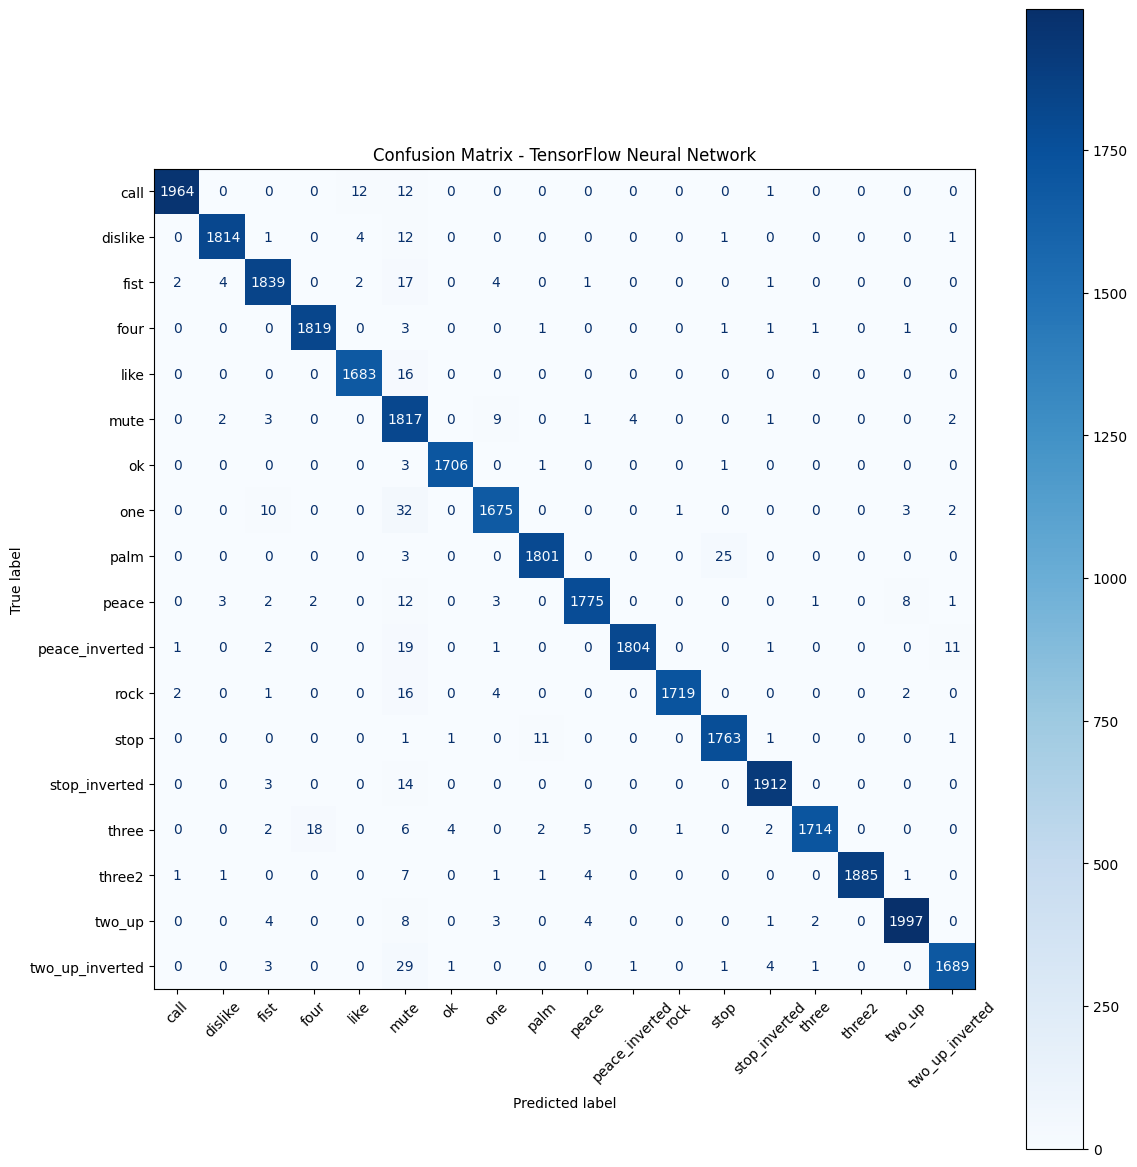

In [80]:
# best_model_result = results_df.iloc[0]
# ConfusionMatrixDisplay(confusion_matrix=best_model_result['Confusion Matrix'],
#                        display_labels=['Stayed', 'Exited']).plot(cmap='Blues')
# plt.title(f"Confusion Matrix - {best_model_result['Model']}")
# plt.show()


# ดึง class ที่มีใน test จริงๆ
classes_in_test = le.classes_[np.unique(Y_test_enc)]

best_model_result = results_df.iloc[0]

fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay(
    confusion_matrix=best_model_result['Confusion Matrix'],
    display_labels=classes_in_test
).plot(cmap='Blues', xticks_rotation=45, ax=ax)

plt.title(f"Confusion Matrix - {best_model_result['Model']}")
plt.tight_layout()
plt.show()

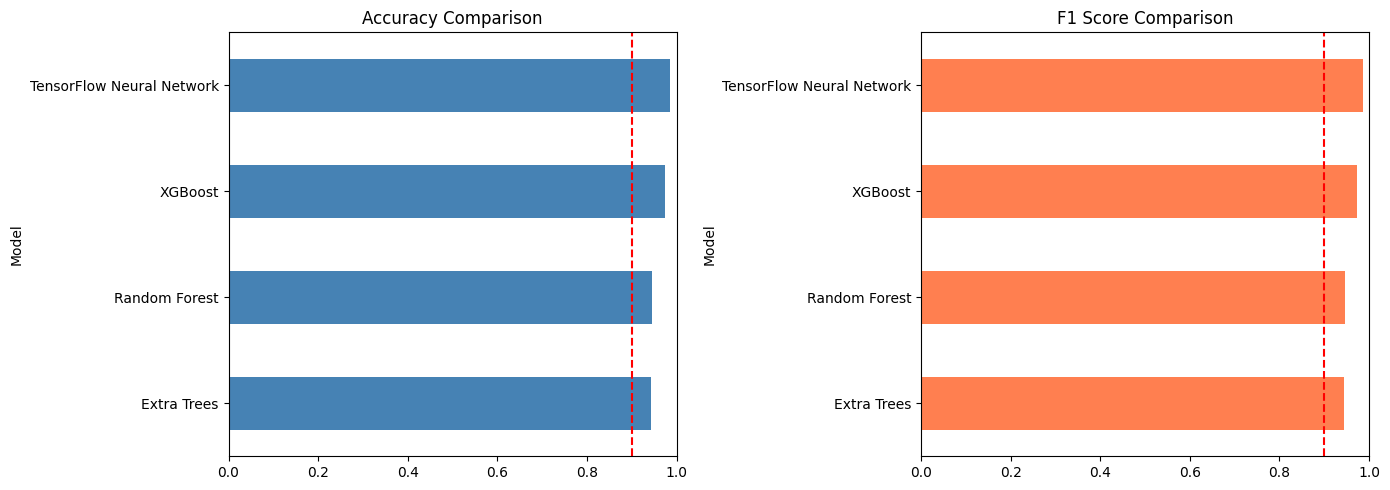

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'F1 Score']
colors  = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    results_df.sort_values(metric).plot(
        kind='barh', x='Model', y=metric,
        ax=axes[i], color=colors[i], legend=False
    )
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xlim(0, 1)
    axes[i].axvline(x=0.9, color='red', linestyle='--')

plt.tight_layout()
plt.show()

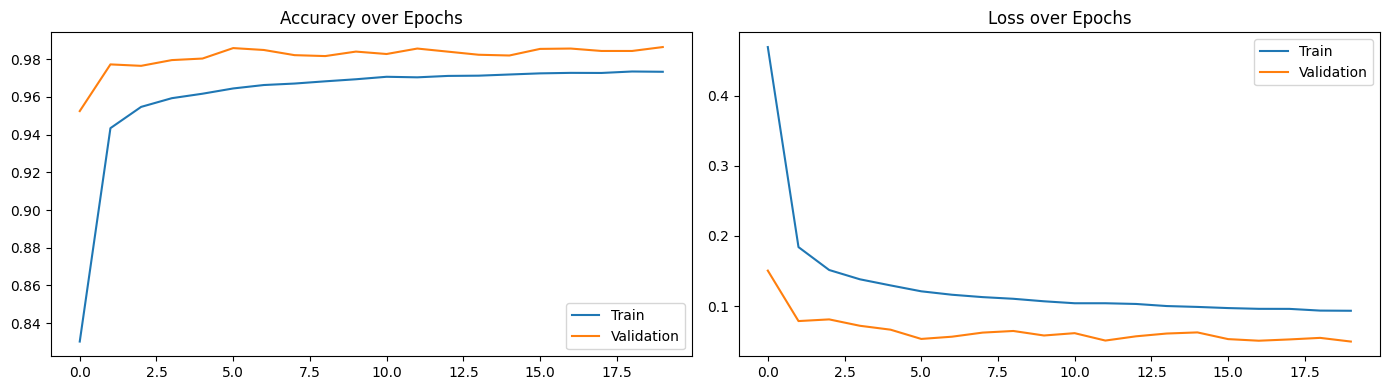

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

- เซฟโมเดล

In [83]:
tf_model.save("MyGestureProject-bata-V.1.0.keras")
print("💾 เซฟโมเดล TensorFlow เรียบร้อย -> ไฟล์: MyGestureProject-bata-V.1.0.keras")

💾 เซฟโมเดล TensorFlow เรียบร้อย -> ไฟล์: MyGestureProject-bata-V.1.0.keras


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

- เช็คCPU REM DISK

In [84]:
import psutil
ram = psutil.virtual_memory()
print(f"📊 [RAM] ทั้งหมด: {ram.total / (1024**3):.2f} GB")
print(f"📊 [RAM] กำลังใช้งาน: {ram.used / (1024**3):.2f} GB")
print(f"📊 [RAM] เหลือให้ใช้: {ram.available / (1024**3):.2f} GB ({ram.percent}%)")

print("-" * 40)

# 2. เช็กพื้นที่ Harddisk (Disk Space)
disk = psutil.disk_usage('/')
print(f"💾 [Disk] ความจุทั้งหมด: {disk.total / (1024**3):.2f} GB")
print(f"💾 [Disk] ถูกใช้งานไป: {disk.used / (1024**3):.2f} GB")
print(f"💾 [Disk] พื้นที่ว่าง: {disk.free / (1024**3):.2f} GB ({disk.percent}%)")

print("-" * 40)

# 3. เช็กจำนวนคอร์ CPU
print(f"🧠 [CPU] จำนวนคอร์ทั้งหมด: {os.cpu_count()} Cores")

📊 [RAM] ทั้งหมด: 12.67 GB
📊 [RAM] กำลังใช้งาน: 9.75 GB
📊 [RAM] เหลือให้ใช้: 2.64 GB (79.2%)
----------------------------------------
💾 [Disk] ความจุทั้งหมด: 107.72 GB
💾 [Disk] ถูกใช้งานไป: 22.13 GB
💾 [Disk] พื้นที่ว่าง: 85.57 GB (20.5%)
----------------------------------------
🧠 [CPU] จำนวนคอร์ทั้งหมด: 2 Cores


# save ไฟล์label กับ โมเดลไว้ใช้ต่อ

In [85]:
import joblib
from google.colab import files

# save
tf_model.save("MyGestureProject_bata_V1_0.h5")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

# download ลงเครื่อง
files.download("MyGestureProject_bata_V1_0.h5")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# import gc

# ตัวอย่าง: พอได้ตาราง df_dummies มาแล้ว และไม่คิดจะใช้ตาราง df ตัวเดิมอีกต่อไป
# del df   # สั่งลบตารางเก่าทิ้งจากหน่วยความจำ
# gc.collect()  # สั่งเคลียร์พื้นที่ RAM คืนให้ระบบทันที

In [ ]:
# import os


# os._exit(0)